# EfficientNetB0 — Comparison: Exp1 vs Exp2 vs Exp3
Loads saved results CSVs and produces full comparison with charts and summary table.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load Results (add exp-results folder as Kaggle input) ─
exp1 = pd.read_csv('/kaggle/input/notebooks/elaffa/01-efficientnetb0-exp1-frozen/exp1_results.csv')
exp2 = pd.read_csv('/kaggle/input/notebooks/elaffa/02-efficientnetb0-exp2-augmentation/exp2_results.csv')
exp3 = pd.read_csv('/kaggle/input/notebooks/elaffa/03-efficientnetb0-exp3-finetuning/exp3_results.csv')

results = pd.concat([exp1, exp2, exp3], ignore_index=True)
print(results.to_string(index=False))

       experiment          model  test_acc  test_loss  f1_weighted  precision  recall
    Exp1 - Frozen EfficientNetB0    0.9085     0.2712       0.9065     0.9124  0.9085
Exp2 - Frozen+Aug EfficientNetB0    0.8923     0.3308       0.8928     0.9025  0.8923
Exp3 - Fine-Tuned EfficientNetB0    0.8668     0.4241       0.8672     0.8794  0.8668


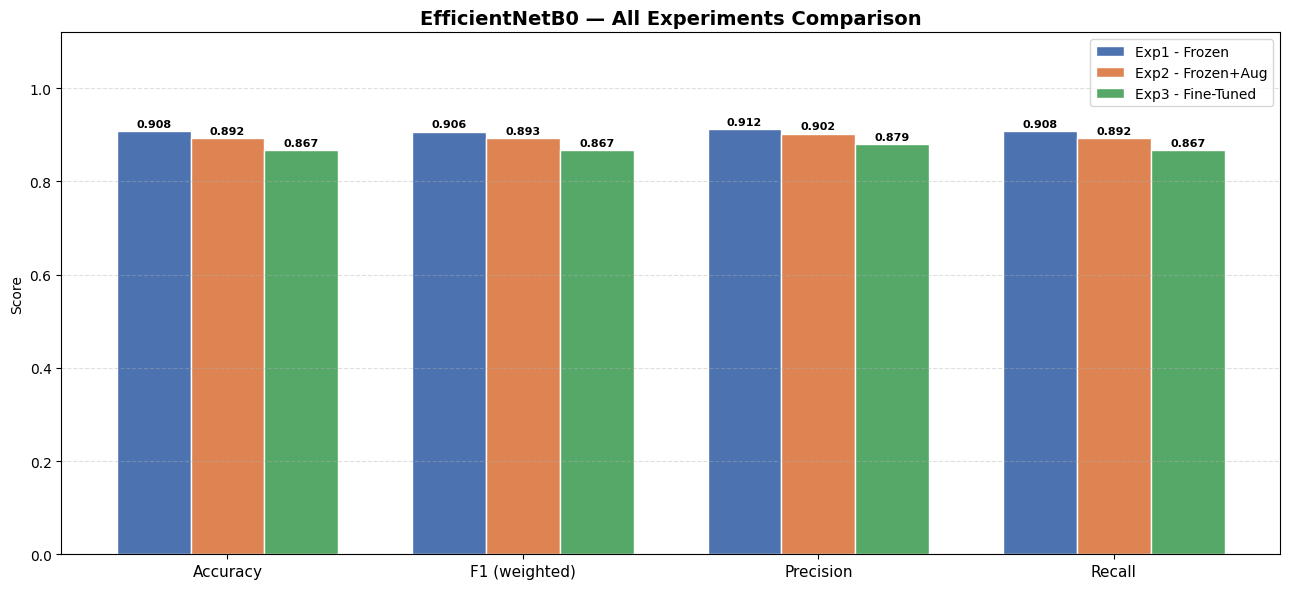

In [2]:
# ── Grouped Bar Chart: All Metrics ──────────────────────
metrics    = ['test_acc', 'f1_weighted', 'precision', 'recall']
labels     = ['Accuracy', 'F1 (weighted)', 'Precision', 'Recall']
colors     = ['#4C72B0', '#DD8452', '#55A868']
x          = np.arange(len(metrics))
width      = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (_, row) in enumerate(results.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width,
                  label=row['experiment'], color=colors[i], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('EfficientNetB0 — All Experiments Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/efficientnet_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

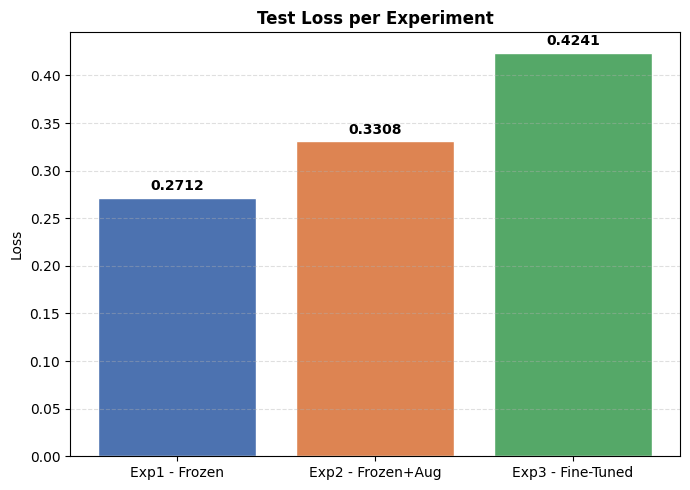

In [3]:
# ── Test Loss Comparison ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(results['experiment'], results['test_loss'],
              color=colors[:len(results)], edgecolor='white')
for bar, val in zip(bars, results['test_loss']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Test Loss per Experiment', fontweight='bold')
ax.set_ylabel('Loss')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/efficientnet_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ── Summary Table ────────────────────────────────────────
print('='*65)
print('EFFICIENTNETB0 — EXPERIMENT COMPARISON SUMMARY')
print('='*65)
print(results[['experiment','test_acc','f1_weighted','precision','recall','test_loss']].to_string(index=False))
print('='*65)

best = results.loc[results['f1_weighted'].idxmax()]
print(f'\nBest experiment (by F1-weighted): {best["experiment"]}')
print(f'   Accuracy  : {best["test_acc"]:.4f}')
print(f'   F1        : {best["f1_weighted"]:.4f}')
print(f'   Precision : {best["precision"]:.4f}')
print(f'   Recall    : {best["recall"]:.4f}')
print(f'   Loss      : {best["test_loss"]:.4f}')

EFFICIENTNETB0 — EXPERIMENT COMPARISON SUMMARY
       experiment  test_acc  f1_weighted  precision  recall  test_loss
    Exp1 - Frozen    0.9085       0.9065     0.9124  0.9085     0.2712
Exp2 - Frozen+Aug    0.8923       0.8928     0.9025  0.8923     0.3308
Exp3 - Fine-Tuned    0.8668       0.8672     0.8794  0.8668     0.4241

Best experiment (by F1-weighted): Exp1 - Frozen
   Accuracy  : 0.9085
   F1        : 0.9065
   Precision : 0.9124
   Recall    : 0.9085
   Loss      : 0.2712
